In [1]:
pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.6/148.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.0/165.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.0/70.0 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.14.1 requires websockets<16.0.0,>=15.0.1, but you have websockets 13.1 which is incompatible.
dataproc-spark-connect 0.8.3 requires websockets>=14.0, but you have websockets 13.1 which is incompatible.


In [3]:
import pandas as pd
import fastf1
import matplotlib.pyplot as plt

## BASICS

In [5]:
session = fastf1.get_session(2024, 'monaco', 'R')
session.load()
session.results

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.6.1]
INFO:fastf1.fastf1.core:Loading data for Monaco Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_dat

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
16,16,C LECLERC,LEC,leclerc,Ferrari,E80020,ferrari,Charles,Leclerc,Charles Leclerc,...,1.0,1,1.0,NaT,NaT,NaT,0 days 02:23:15.554000,Finished,25.0,78.0
81,81,O PIASTRI,PIA,piastri,McLaren,FF8000,mclaren,Oscar,Piastri,Oscar Piastri,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:07.152000,Finished,18.0,78.0
55,55,C SAINZ,SAI,sainz,Ferrari,E80020,ferrari,Carlos,Sainz,Carlos Sainz,...,3.0,3,3.0,NaT,NaT,NaT,0 days 00:00:07.585000,Finished,15.0,78.0
4,4,L NORRIS,NOR,norris,McLaren,FF8000,mclaren,Lando,Norris,Lando Norris,...,4.0,4,4.0,NaT,NaT,NaT,0 days 00:00:08.650000,Finished,12.0,78.0
63,63,G RUSSELL,RUS,russell,Mercedes,27F4D2,mercedes,George,Russell,George Russell,...,5.0,5,5.0,NaT,NaT,NaT,0 days 00:00:13.309000,Finished,10.0,78.0
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,3671C6,red_bull,Max,Verstappen,Max Verstappen,...,6.0,6,6.0,NaT,NaT,NaT,0 days 00:00:13.853000,Finished,8.0,78.0
44,44,L HAMILTON,HAM,hamilton,Mercedes,27F4D2,mercedes,Lewis,Hamilton,Lewis Hamilton,...,7.0,7,7.0,NaT,NaT,NaT,0 days 00:00:14.908000,Finished,7.0,78.0
22,22,Y TSUNODA,TSU,tsunoda,RB,6692FF,rb,Yuki,Tsunoda,Yuki Tsunoda,...,8.0,8,8.0,NaT,NaT,NaT,0 days 00:00:39.487000,Lapped,4.0,77.0
23,23,A ALBON,ALB,albon,Williams,64C4FF,williams,Alexander,Albon,Alexander Albon,...,9.0,9,9.0,NaT,NaT,NaT,0 days 00:00:54.052000,Lapped,2.0,77.0
10,10,P GASLY,GAS,gasly,Alpine,0093cc,alpine,Pierre,Gasly,Pierre Gasly,...,10.0,10,10.0,NaT,NaT,NaT,0 days 00:01:00.241000,Lapped,1.0,77.0


In [7]:
session.results[['BroadcastName', 'Position', 'Points']].iloc[0:10]

,BroadcastName,Position,Points
16,C LECLERC,1.0,25.0
81,O PIASTRI,2.0,18.0
55,C SAINZ,3.0,15.0
4,L NORRIS,4.0,12.0
63,G RUSSELL,5.0,10.0
1,M VERSTAPPEN,6.0,8.0
44,L HAMILTON,7.0,7.0
22,Y TSUNODA,8.0,4.0
23,A ALBON,9.0,2.0
10,P GASLY,10.0,1.0


In [8]:
session = fastf1.get_session(2025, 'japan', 'Q')
session.load()
session.laps.columns

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
INFO:fastf1.fastf1.core:Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for se

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [9]:
fastest_lap = session.laps.pick_fastest()
fastest_lap[['Driver', "LapTime"]]

,0
Driver,VER
LapTime,0 days 00:01:26.983000


## Plotting from fastf1

### 1. qualifying results overview

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from timple.timedelta import strftimedelta

import fastf1
import fastf1.plotting
from fastf1.core import Laps

In [11]:
# Enable Matplotlib patches for plotting timedelta values
fastf1.plotting.setup_mpl(mpl_timedelta_support = True, color_scheme = None)

session = fastf1.get_session(2025, 'Monza', 'Q')
session.load()

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.6.1]
INFO:fastf1.fastf1.core:Loading data for Italian Grand Prix - Qualifying [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for sess

In [13]:
# array of all the drivers
drivers = pd.unique(session.laps['Driver'])
drivers

array(['VER', 'NOR', 'PIA', 'LEC', 'HAM', 'RUS', 'ANT', 'BOR', 'ALO',
       'TSU', 'BEA', 'HUL', 'SAI', 'ALB', 'OCO', 'HAD', 'STR', 'COL',
       'GAS', 'LAW'], dtype=object)

In [14]:
# list of all the drivers fastest_laps
list_fastest_laps = list()
for d in drivers:
  d_fastest_laps = session.laps.pick_drivers(d).pick_fastest()
  list_fastest_laps.append(d_fastest_laps)
fastest_laps = Laps(list_fastest_laps).sort_values(by = 'LapTime').reset_index(drop = True)

In [16]:
pole_lap = fastest_laps.pick_fastest()
fastest_laps['LapTimeDelta'] = fastest_laps['LapTime'] - pole_lap['LapTime']
fastest_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeDelta'],
      dtype='object')

In [17]:
fastest_laps[['Driver', 'LapTime', 'LapTimeDelta']]

,Driver,LapTime,LapTimeDelta
0,VER,0 days 00:01:18.792000,0 days 00:00:00
1,NOR,0 days 00:01:18.869000,0 days 00:00:00.077000
2,PIA,0 days 00:01:18.982000,0 days 00:00:00.190000
3,LEC,0 days 00:01:19.007000,0 days 00:00:00.215000
4,HAM,0 days 00:01:19.124000,0 days 00:00:00.332000
5,RUS,0 days 00:01:19.157000,0 days 00:00:00.365000
6,ANT,0 days 00:01:19.200000,0 days 00:00:00.408000
7,BOR,0 days 00:01:19.323000,0 days 00:00:00.531000
8,ALO,0 days 00:01:19.362000,0 days 00:00:00.570000
9,TSU,0 days 00:01:19.433000,0 days 00:00:00.641000


In [18]:
# create a list of team colors per lap to clour our plot
team_colors = list()
for i, lap in fastest_laps.iterlaps():
  color = fastf1.plotting.get_team_color(lap['Team'], session = session)
  team_colors.append(color)

req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info


In [19]:
pole_lap

,0
Time,0 days 01:14:52.170000
Driver,VER
DriverNumber,1
LapTime,0 days 00:01:18.792000
LapNumber,17.0
Stint,6.0
PitOutTime,NaT
PitInTime,NaT
Sector1Time,0 days 00:00:26.262000
Sector2Time,0 days 00:00:26.483000


Text(0.5, 0.98, 'Italian Grand Prix 2025 Qualifying\nFastest lap:01:18.792 (VER)')

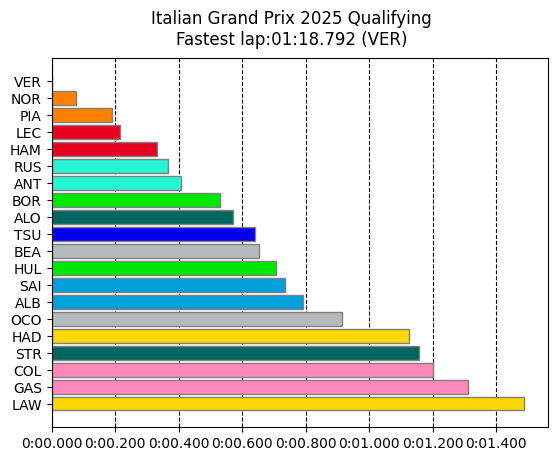

In [21]:
#plot the data
fig, ax = plt.subplots()
ax.barh(fastest_laps.index, fastest_laps['LapTimeDelta'], color = team_colors, edgecolor = 'grey')
ax.set_yticks(fastest_laps.index)
ax.set_yticklabels(fastest_laps['Driver'])

# show fastest at the top
ax.invert_yaxis()

# draw vertical lines behind the bars
ax.set_axisbelow(True)
ax.xaxis.grid(True, which = 'major', linestyle = '--', color = 'black', zorder =- 1000)

lap_time_string = strftimedelta(pole_lap['LapTime'], '%m:%s.%ms')
plt.suptitle(f"{session.event['EventName']} {session.event.year} Qualifying\n"f"Fastest lap:{lap_time_string} ({pole_lap["Driver"]})")

### 2. Overlaying speed traces of two laps

In [23]:
# select the laps you want to comapare lets do verstappen and norris
ver_lap = session.laps.pick_drivers('VER').pick_fastest()
nor_lap = session.laps.pick_drivers('NOR').pick_fastest()

ver_tel = ver_lap.get_car_data().add_distance()
nor_tel = nor_lap.get_car_data().add_distance()

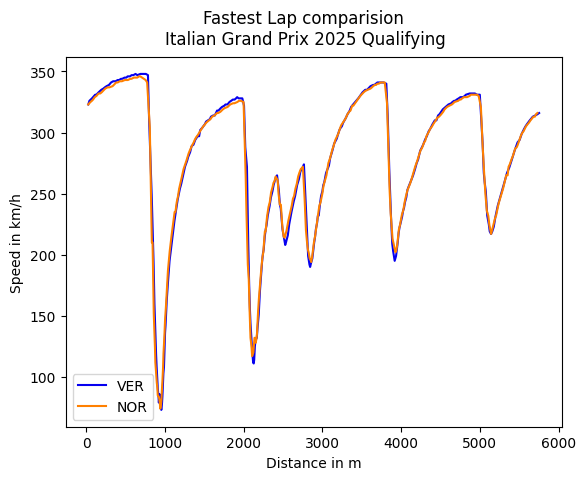

In [24]:
rb_color = fastf1.plotting.get_team_color(ver_lap['Team'], session = session)
ml_color = fastf1.plotting.get_team_color(nor_lap['Team'], session = session)

fig,ax = plt.subplots()
ax.plot(ver_tel['Distance'], ver_tel['Speed'], color = rb_color, label = 'VER')
ax.plot(nor_tel['Distance'], nor_tel['Speed'], color = ml_color, label = 'NOR')

ax.set_xlabel('Distance in m')
ax.set_ylabel('Speed in km/h')

ax.legend()
plt.suptitle(f"Fastest Lap comparision \n"f"{session.event["EventName"]} {session.event.year} Qualifying")
plt.show()

In [29]:
#lets compare tsunoda and verstapen
law_lap = session.laps.pick_drivers('LAW').pick_fastest()
law_tel = law_lap.get_car_data().add_distance()

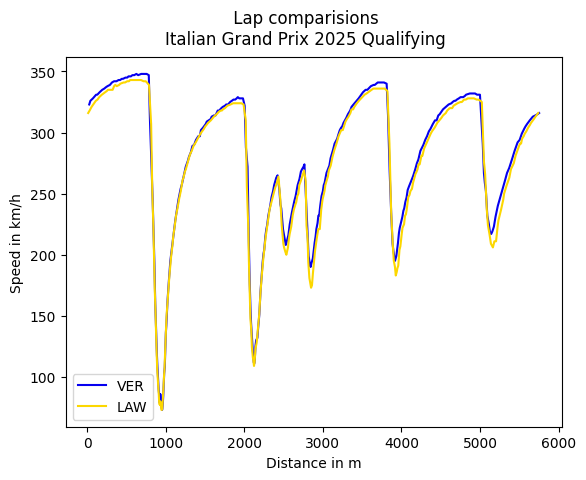

In [30]:
visa_color = fastf1.plotting.get_team_color(law_lap['Team'], session = session)

fig,ax = plt.subplots()
ax.plot(ver_tel['Distance'], ver_tel['Speed'], color = rb_color, label = 'VER')
ax.plot(law_tel['Distance'], law_tel['Speed'], color = visa_color, label = 'LAW')

ax.set_xlabel('Distance in m')
ax.set_ylabel('Speed in km/h')

ax.legend()
plt.suptitle(f" Lap comparisions \n"f"{session.event["EventName"]} {session.event.year} Qualifying")
plt.show()